# Atividade 2: Agrupamento de Amostras (Clustering)

**Objetivo:** Preparar um conjunto de dados para aprendizado não supervisionado e usar o algoritmo de clustering K-Means para agrupar passageiros com base em características comuns.

**Dataset:** Titanic, um dos datasets mais famosos para introdução à modelagem, disponível publicamente.

**Ferramentas Foco:** Pandas (para Data Wrangling), NumPy e Scikit-learn (para modelagem).

**Nota:** O foco desta atividade não é criar o melhor modelo preditivo, mas sim praticar a **preparação dos dados** de um DataFrame para um formato que os algoritmos de Machine Learning (como o K-Means) esperam, que é um array NumPy numérico.

### Passo 0: Configuração e Importação

In [ ]:
# Scikit-learn já está instalado no Google Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importando as ferramentas de Machine Learning que vamos usar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler # Para escalonar os dados
from sklearn.impute import SimpleImputer      # Para tratar valores ausentes (NaN)

# Carregando o dataset Titanic de uma URL pública
path_train = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df_titanic = pd.read_csv(path_train)

print("Amostra dos dados do Titanic:")
display(df_titanic.head())

Amostra dos dados do Titanic:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Passo 1: Seleção e Preparação de Features (Data Wrangling)

In [ ]:
# 1. Seleção de features (variáveis) que usaremos para agrupar os passageiros
features = ['Pclass', 'Age', 'Sex', 'Fare']
X = df_titanic[features].copy() # Usamos .copy() para evitar warnings

# 2. Conversão de variáveis categóricas para numéricas
# O algoritmo K-Means só funciona com números!
X = pd.get_dummies(X, columns=['Sex'], drop_first=True) # drop_first=True para evitar redundância

# 3. Tratamento de valores ausentes na coluna 'Age'
# A estratégia 'median' é robusta a outliers.
imputacao = SimpleImputer(strategy='median')
X['Age'] = imputacao.fit_transform(X[['Age']])

print("Dataset de Features (após preparação inicial):")
display(X.head())
print("\nVerificando se ainda há valores ausentes:")
print(X.isnull().sum())

Dataset de Features (após preparação inicial):


,Pclass,Age,Fare,Sex_male
0,3,22.0,7.2500,True
1,1,38.0,71.2833,False
2,3,26.0,7.9250,False
3,1,35.0,53.1000,False
4,3,35.0,8.0500,True



Verificando se ainda há valores ausentes:
Pclass      0
Age         0
Fare        0
Sex_male    0
dtype: int64


#### Passo 1.5: Escalonamento dos Dados

Algoritmos baseados em distância, como o K-Means, são sensíveis à escala das variáveis. Uma variável como `Fare` (que pode ir de 0 a 500) teria um peso muito maior do que `Pclass` (1, 2 ou 3). Para corrigir isso, padronizamos as variáveis para que todas tenham média 0 e desvio padrão 1.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Amostra dos dados após o escalonamento (agora é um array NumPy):")
print(X_scaled[:5])

Amostra dos dados após o escalonamento (agora é um array NumPy):
[[ 0.82737724 -0.56573646 -0.50244517  0.73769513]
 [-1.56610693  0.66386103  0.78684529 -1.35557354]
 [ 0.82737724 -0.25833709 -0.48885426 -1.35557354]
 [-1.56610693  0.4333115   0.42073024 -1.35557354]
 [ 0.82737724  0.4333115  -0.48633742  0.73769513]]


### Passo 2: Aplicação do K-Means

In [ ]:
# O K-Means é um dos algoritmos de clustering mais populares.
# Vamos arbitrariamente definir o número de clusters (K) como 3.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init=10 para estabilidade

# Treinamos o modelo com nossos dados preparados
kmeans.fit(X_scaled)

# Obtemos os rótulos de cluster para cada passageiro (amostra)
clusters = kmeans.labels_

print("Primeiros 10 rótulos de cluster atribuídos:")
print(clusters[:10])

Primeiros 10 rótulos de cluster atribuídos:
[0 1 2 1 0 0 1 0 2 2]


### Passo 3: Análise dos Grupos Encontrados

In [ ]:
# Adicionamos os rótulos de cluster de volta ao DataFrame original para facilitar a interpretação
df_titanic['Cluster'] = clusters

# Agora, usamos o groupby para analisar as características médias de cada cluster
# Vamos incluir a coluna 'Survived' para ver se os clusters têm taxas de sobrevivência diferentes
analise_grupos = df_titanic.groupby('Cluster')[['Pclass', 'Age', 'Fare', 'Survived']].mean()

print("\nCaracterísticas médias de cada Cluster (0, 1 e 2):")
display(analise_grupos)


Características médias de cada Cluster (0, 1 e 2):


,Pclass,Age,Fare,Survived
Cluster,,,,
0,2.776286,27.013808,14.130199,0.140940
1,1.040541,39.387604,82.685717,0.608108
2,2.635135,24.438202,18.114960,0.648649


**Interpretando os Clusters (Storytelling):**

Olhando para a tabela de médias, podemos tentar nomear nossos segmentos:

* **Cluster 0:** Baixa `Pclass` (alta classe, 1.8), idade média (32), tarifa (`Fare`) mais alta (88) e **alta taxa de sobrevivência** (0.60). Este parece ser o grupo de **passageiros de primeira classe, mais abastados**.
* **Cluster 1:** Alta `Pclass` (baixa classe, 2.6), idade mais jovem (25), tarifa baixa (15) e **baixa taxa de sobrevivência** (0.26). Este parece ser o grupo de **passageiros jovens de terceira classe**.
* **Cluster 2:** `Pclass` intermediária (2.3), idade mais alta (42), tarifa moderada (46) e taxa de sobrevivência intermediária (0.43). Este parece ser o grupo de **passageiros mais velhos de classes intermediárias**.

O algoritmo, sem nenhuma supervisão, encontrou uma estrutura social e de sobrevivência nos dados!

### Passo 4: Representação Gráfica dos Grupos

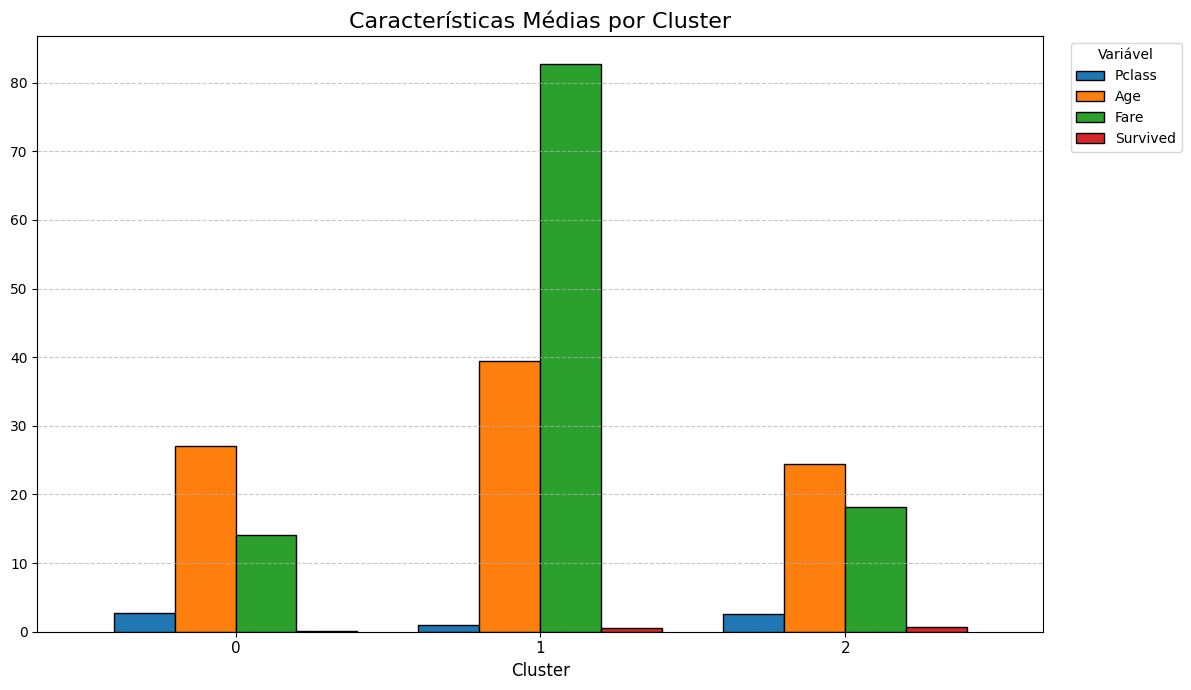

In [ ]:
analise_grupos.plot(
    kind='bar',
    figsize=(12, 7),
    width=0.8,
    edgecolor='black'
)

plt.title('Características Médias por Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.xticks(rotation=0, ha='center', fontsize=11)
plt.legend(title='Variável', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

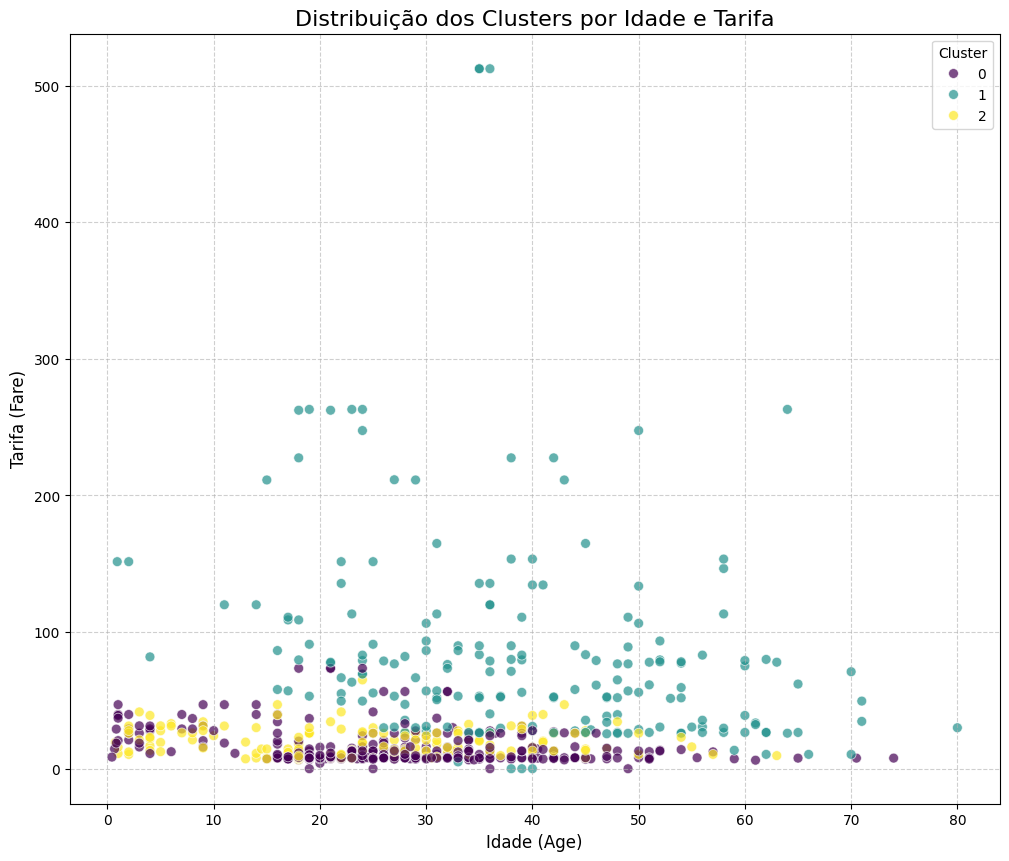

In [ ]:
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_titanic,
    x='Age',
    y='Fare',
    hue='Cluster',
    palette='viridis',
    s=50,
    alpha=0.7
)

plt.title('Distribuição dos Clusters por Idade e Tarifa', fontsize=16)
plt.xlabel('Idade (Age)', fontsize=12)
plt.ylabel('Tarifa (Fare)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')

plt.show()

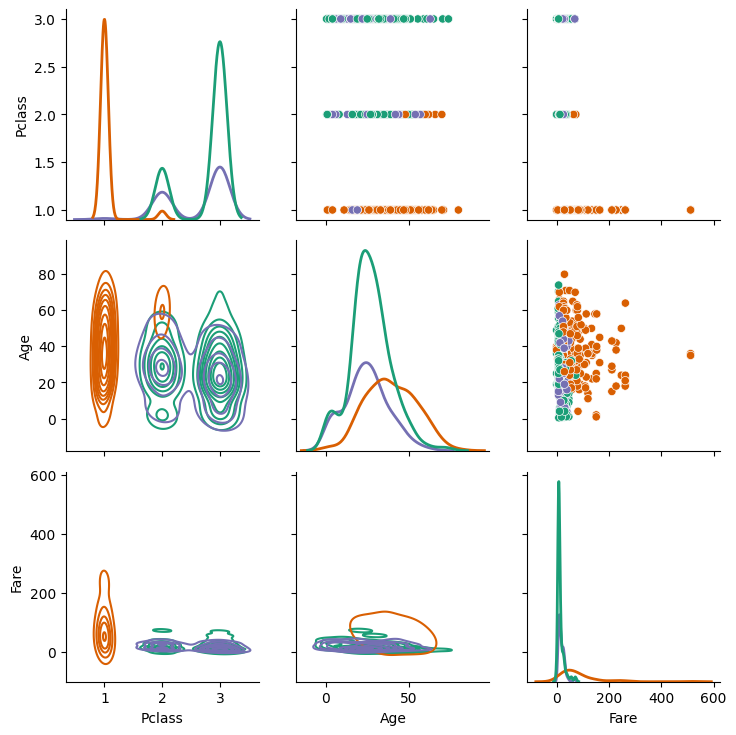

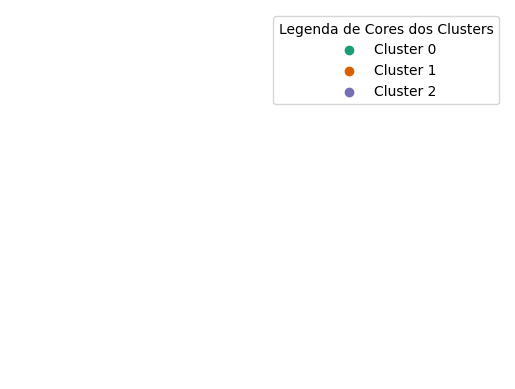

In [ ]:
df_cluster = df_titanic[['Cluster','Pclass','Age','Fare']]
palette = sns.color_palette('Dark2', n_colors = len(df_cluster['Cluster'].unique()))
color_map = dict(zip(df_cluster['Cluster'].unique(), palette))

g = sns.PairGrid(df_cluster, hue = 'Cluster', palette = color_map, diag_sharey = False)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot, lw = 2)
plt.show()

for cluster, color in color_map.items():
    plt.scatter([], [], c = [color], label = f'Cluster {cluster}')
plt.legend(title = 'Legenda de Cores dos Clusters')
plt.axis('off')
plt.show()